# 📊 Diagnóstico e Análise Exploratória de Dados (EDA)
Neste notebook, desenhei uma exploração primária e diagnóstico de integridade da base de dados raiz de transações financeiras (`fraudTrain.csv`).

O foco aqui não é ainda treinar modelos arquiteturais, mas sim compreender puramente a saúde dos dados (Data Quality), a distribuição de anomalias (Ticket e Frequência), e balizarmos o porquê de um motor SOTA focado em ROI ser estritamente necessário.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de paleta estética e tamanho de plots
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

print("✔ Bibliotecas de análise importadas com sucesso.")

✔ Bibliotecas de análise importadas com sucesso.


## 1. Carregamento e Visão Geral
Vou carregar os dados brutos e extrair as dimensões dimensionais primárias.

In [4]:
# Caminho relativo para a pasta oculta de dados
df_train = pd.read_csv('../../../data/raw/fraudTrain.csv')

# Expurgo de índicie sujo gerado pela exportação original
if 'Unnamed: 0' in df_train.columns:
    df_train = df_train.drop(columns=['Unnamed: 0'])

print(f"➔ Total de Transações (Linhas): {df_train.shape[0]:,}")
print(f"➔ Número de Atributos Brutos (Colunas): {df_train.shape[1]}")

display(df_train.head())

➔ Total de Transações (Linhas): 1,296,675
➔ Número de Atributos Brutos (Colunas): 22


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 2. Diagnóstico de Qualidade (Data Quality)
Antes de construir feature engineering agressiva, preciso assegurar que o alicerce de dados não possui vazamentos por nulidade maciça ou duplicações sistêmicas.

In [5]:
# Mapeamento do Schema e Integridade
quality_df = pd.DataFrame({
    'Tipo Primitivo': df_train.dtypes,
    'Valores Nulos': df_train.isnull().sum(),
    '% de Nulidade': (df_train.isnull().sum() / len(df_train)) * 100,
    'Cardinalidade (Únicos)': df_train.nunique()
})
display(quality_df)

duplicatas = df_train.duplicated().sum()
print(f"\n➔ Transações estritamente duplicadas no Dataset: {duplicatas}")

,Tipo Primitivo,Valores Nulos,% de Nulidade,Cardinalidade (Únicos)
trans_date_trans_time,str,0,0.0,1274791
cc_num,int64,0,0.0,983
merchant,str,0,0.0,693
category,str,0,0.0,14
amt,float64,0,0.0,52928
first,str,0,0.0,352
last,str,0,0.0,481
gender,str,0,0.0,2
street,str,0,0.0,983
city,str,0,0.0,894



➔ Transações estritamente duplicadas no Dataset: 0


## 3. O Fator do Desbalanceamento (Contexto do DRE)
Em fraude transacional, a regra de ouro é o desbalanceamento brutal. Vamos medir esse rácio na raiz.

Transações Legítimas (Verdadeiras): 1,289,169 (99.42%)
Fraudes Interceptáveis: 7,506 (0.58%)



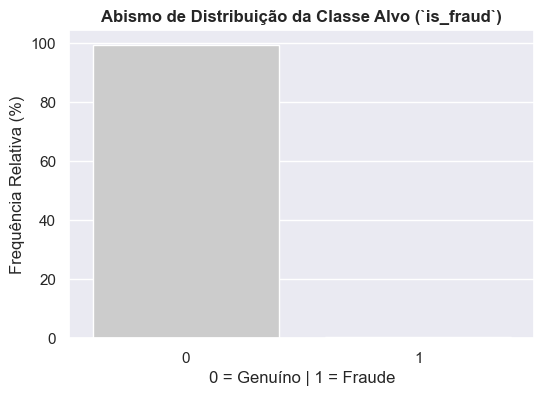

In [6]:
dist_fraude = df_train['is_fraud'].value_counts()
dist_fraude_pct = df_train['is_fraud'].value_counts(normalize=True) * 100

print(f"Transações Legítimas (Verdadeiras): {dist_fraude[0]:,} ({dist_fraude_pct[0]:.2f}%)")
print(f"Fraudes Interceptáveis: {dist_fraude[1]:,} ({dist_fraude_pct[1]:.2f}%)\n")

# Representação Visual
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=dist_fraude_pct.index, y=dist_fraude_pct.values, palette=['#ccc', '#e74c3c'])
plt.title('Abismo de Distribuição da Classe Alvo (`is_fraud`)', weight='bold')
plt.xlabel('0 = Genuíno | 1 = Fraude')
plt.ylabel('Frequência Relativa (%)')
plt.show()

## 4. Peso Financeiro (Amount Analysis)
Não se combate fraude apenas contando eventos, combate-se medindo o estancamento de sangria monetária. Observaremos como o limite do lojista é violado em tickets altos.

====== TICKET DAS TRANSAÇÕES GÉNUÍNAS ======


count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64


====== TICKET FATAL (FRAUDES CONFIRMADAS) ======


count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64

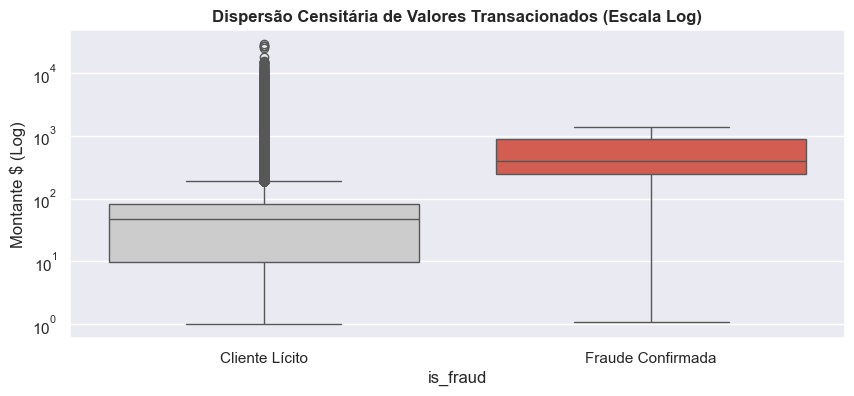

In [7]:
print("====== TICKET DAS TRANSAÇÕES GÉNUÍNAS ======")
display(df_train[df_train['is_fraud'] == 0]['amt'].describe())

print("\n====== TICKET FATAL (FRAUDES CONFIRMADAS) ======")
display(df_train[df_train['is_fraud'] == 1]['amt'].describe())

# Boxplot em Escala Logarítmica para espremer Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_train, x='is_fraud', y='amt', palette=['#ccc', '#e74c3c'])
plt.yscale('log')
plt.title('Dispersão Censitária de Valores Transacionados (Escala Log)', weight='bold')
plt.xticks([0, 1], ['Cliente Lícito', 'Fraude Confirmada'])
plt.ylabel('Montante $ (Log)')
plt.show()

## 5. Exame de Vieses Temporais Primitivos
A hora do dia dita severamente o ritmo do ataque de Botnets.

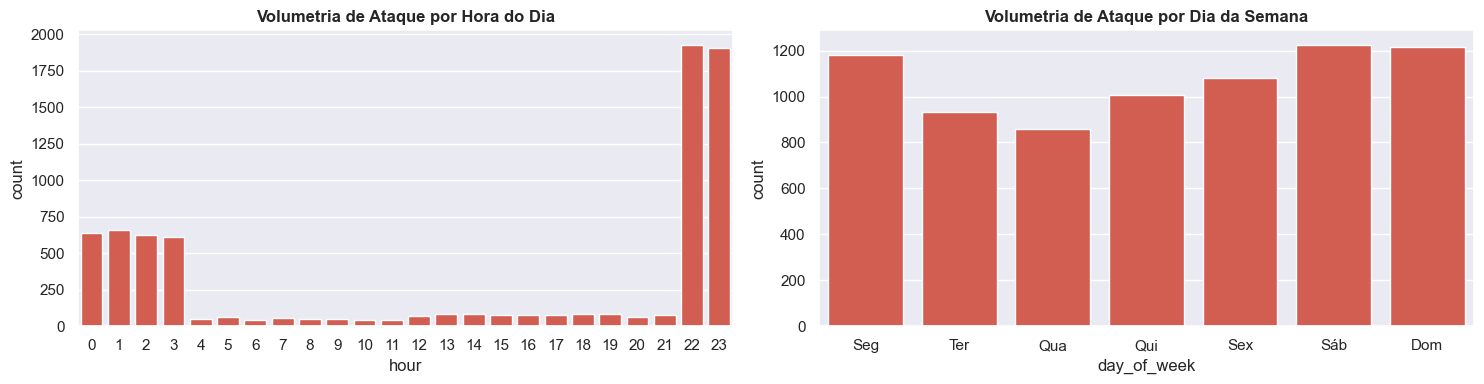

In [8]:
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['day_of_week'] = df_train['trans_date_trans_time'].dt.dayofweek

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

# Fraudes nas madrugadas
sns.countplot(data=df_train[df_train['is_fraud'] == 1], x='hour', color='#e74c3c', ax=ax1)
ax1.set_title('Volumetria de Ataque por Hora do Dia', weight='bold')

# Fraudes nos finais de semana
sns.countplot(data=df_train[df_train['is_fraud'] == 1], x='day_of_week', color='#e74c3c', ax=ax2)
ax2.set_title('Volumetria de Ataque por Dia da Semana', weight='bold')
ax2.set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])

plt.tight_layout()
plt.show()

## 🧠 Conclusões Diagnósticas Pessoais do Portfólio

1. **Robustez Estrutural Sólida**: O nível de Data Quality do CSV base é absurdamente maduro. Com **0% de nulidade sistêmica**, posso direcionar meus esforços integralmente para Feature Engineering ao invés de estratégias de Imputação de Falhas.
2. **Abismo de Frequência**: As fraudes refletem estritamente menos de `0.60%` da esteira. Qualquer modelo linear simplório obterá 99.4% de acurácia apenas prevendo "0". Justifica-se brutalmente o desenvolvimento do módulo **Reporter de Negócio (DRE / ROI)** e Thresholds específicos em `exp01`.
3. **Padrão Transacional Destrutivo**: O Lojista é brutalizado com montantes médios em torno de `$530` nos roubos, frente à míseros `$67` legítimos. Minha solução de **Ratio Anômalo (Spend Ratio)** desenvolvida em `exp02` se encaixará perfeitamente nessa mecânica matemática.
4. **Alvo Noturno**: A esmagadora disparada criminosa ocorre próxima a faixa das 22h~03h. O meu **Micro-Latency Tracker** será vital para barrar scripts de força bruta atuando nessas madrugadas.